## Import thư viện

In [1]:
# Import các thư viện cần thiết cho ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Đọc dữ liệu

In [2]:
# Đọc dữ liệu
columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio", "Liver cirrhosis"
]
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)

display(df)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Liver cirrhosis
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [3]:
df['Liver cirrhosis'] = df['Liver cirrhosis'].map({2:0, 1:1}) 

## Kiểm tra tổng quan dữ liệu

In [4]:
# Thông tin tổng quan về DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Liver cirrhosis             583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


In [5]:
# Thống kê mô tả
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Protiens,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Liver cirrhosis,583.0,0.713551,0.452490,0.0,0.0,1.00,1.0,1.0


## Phân bố target (Liver cirrhosis)

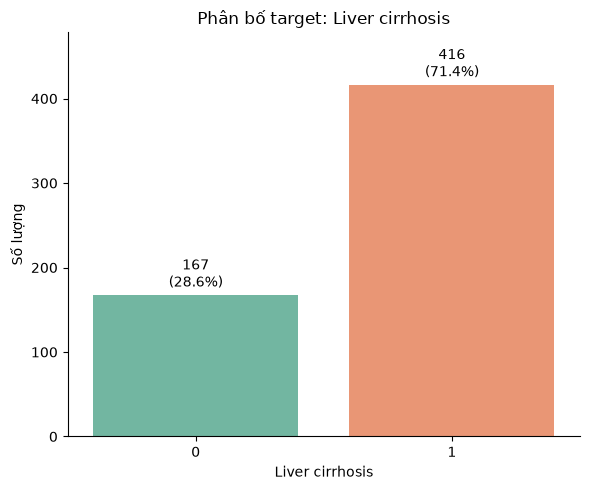

In [6]:
# Bar plot: phân bố target Liver cirrhosis (số đếm + %)
counts = df['Liver cirrhosis'].value_counts().sort_index()
pct = counts / counts.sum() * 100
labels = [f'{c}\n({p:.1f}%)' for c, p in zip(counts.values, pct.values)]

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=counts.index.astype(str), y=counts.values,
    hue=counts.index.astype(str), palette='Set2', legend=False
)

# seaborn 0.13 tách mỗi cột thành 1 container riêng -> label từng cái
for container, lbl in zip(ax.containers, labels):
    ax.bar_label(container, labels=[lbl], padding=3)

ax.set_title('Phân bố target: Liver cirrhosis')
ax.set_xlabel('Liver cirrhosis')
ax.set_ylabel('Số lượng')
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

## Quan hệ giữa Gender và target

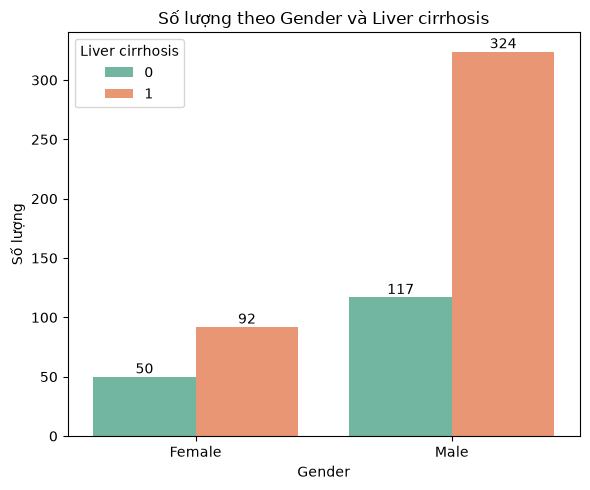

In [7]:
# Bar chart: số lượng theo Gender, phân theo target
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Gender', hue='Liver cirrhosis', palette='Set2')
ax.set_title('Số lượng theo Gender và Liver cirrhosis')
ax.set_xlabel('Gender')
ax.set_ylabel('Số lượng')
ax.legend(title='Liver cirrhosis')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [8]:
# Kiểm định Chi-square: H0 = tỉ lệ mắc bệnh không khác nhau giữa hai giới tính
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Gender'], df['Liver cirrhosis'])
print("Bảng tần số quan sát:")
display(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Bậc tự do: {dof}")
print("\nBảng tần số kỳ vọng (cần >= 5 để Chi-square hợp lệ):")
display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(2))

alpha = 0.05
if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < {alpha} => Bác bỏ H0: có sự khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.")
else:
    print(f"\np-value ({p_value:.4f}) >= {alpha} => Không đủ bằng chứng bác bỏ H0: chưa thấy khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.")

Bảng tần số quan sát:


Liver cirrhosis,0,1
Gender,,
Female,50,92
Male,117,324



Chi-square statistic: 3.5466
p-value: 0.0597
Bậc tự do: 1

Bảng tần số kỳ vọng (cần >= 5 để Chi-square hợp lệ):


Liver cirrhosis,0,1
Gender,,
Female,40.68,101.32
Male,126.32,314.68



p-value (0.0597) >= 0.05 => Không đủ bằng chứng bác bỏ H0: chưa thấy khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.


In [9]:
# Cramér's V: đo độ mạnh của mối liên hệ giữa Gender và Liver cirrhosis
import numpy as np

# Dùng chi2 không hiệu chỉnh Yates cho effect size (chuẩn khi tính Cramér's V)
chi2_raw, p_raw, dof_raw, _ = chi2_contingency(contingency, correction=False)

n = contingency.to_numpy().sum()
r, k = contingency.shape
cramers_v = np.sqrt(chi2_raw / (n * (min(r, k) - 1)))

print(f"Chi-square (không hiệu chỉnh): {chi2_raw:.4f}, p-value: {p_raw:.4f}")
print(f"Cramér's V: {cramers_v:.4f}")

# Ngưỡng tham khảo (Cohen, cho bảng 2x2 / dof=1)
if cramers_v < 0.1:
    strength = "rất yếu / không đáng kể"
elif cramers_v < 0.3:
    strength = "yếu"
elif cramers_v < 0.5:
    strength = "trung bình"
else:
    strength = "mạnh"

print(f"=> Mức độ liên hệ: {strength}")

Chi-square (không hiệu chỉnh): 3.9600, p-value: 0.0466
Cramér's V: 0.0824
=> Mức độ liên hệ: rất yếu / không đáng kể


## Ma trận tương quan giữa các biến số

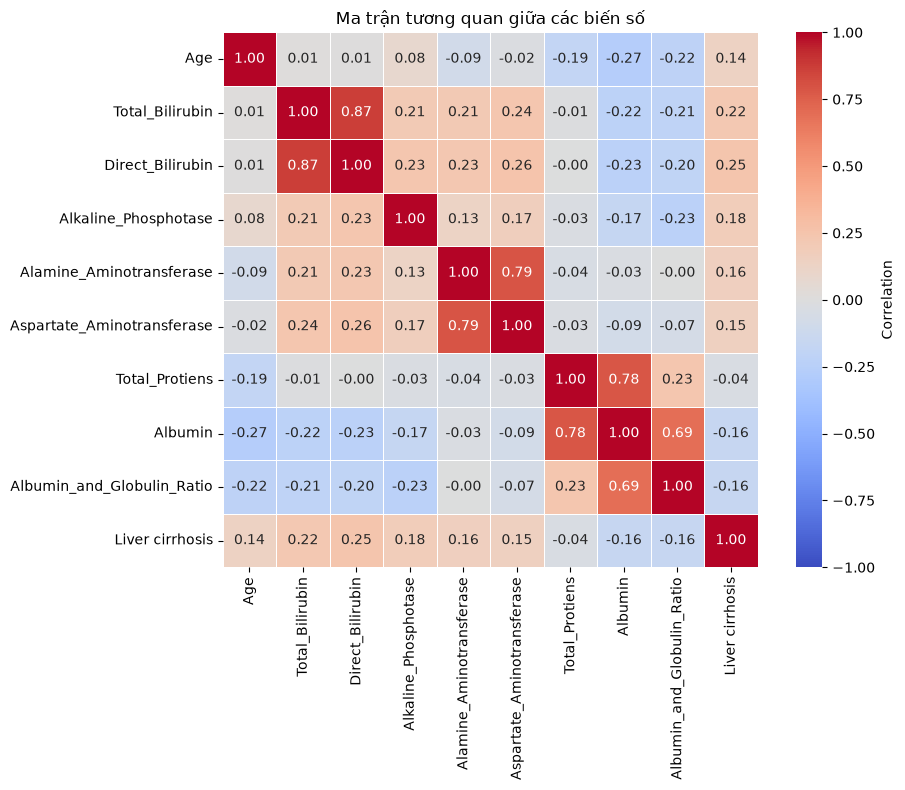

In [10]:
# Ma trận tương quan (bỏ cột Gender vì không phải số)
corr = df.drop(columns=['Gender']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

## Kiểm tra đa cộng tuyến (VIF)

In [11]:
# VIF (Variance Inflation Factor): kiểm tra đa cộng tuyến giữa các feature
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=['Liver cirrhosis']).copy()
X_vif['Gender'] = X_vif['Gender'].map({'Male': 1, 'Female': 0})
X_vif['Albumin_and_Globulin_Ratio'] = X_vif['Albumin_and_Globulin_Ratio'].fillna(
    X_vif['Albumin_and_Globulin_Ratio'].median()
)
X_vif.insert(0, 'const', 1.0)  # VIF cần cột hằng số để chuẩn xác

vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df['Feature'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df

,Feature,VIF
0,Albumin,10.124110
1,Total_Protiens,5.549387
2,Direct_Bilirubin,4.525273
3,Total_Bilirubin,4.277109
4,Albumin_and_Globulin_Ratio,3.682718
5,Alamine_Aminotransferase,2.820379
6,Aspartate_Aminotransferase,2.810927
7,Alkaline_Phosphotase,1.121710
8,Age,1.099327
9,Gender,1.033815


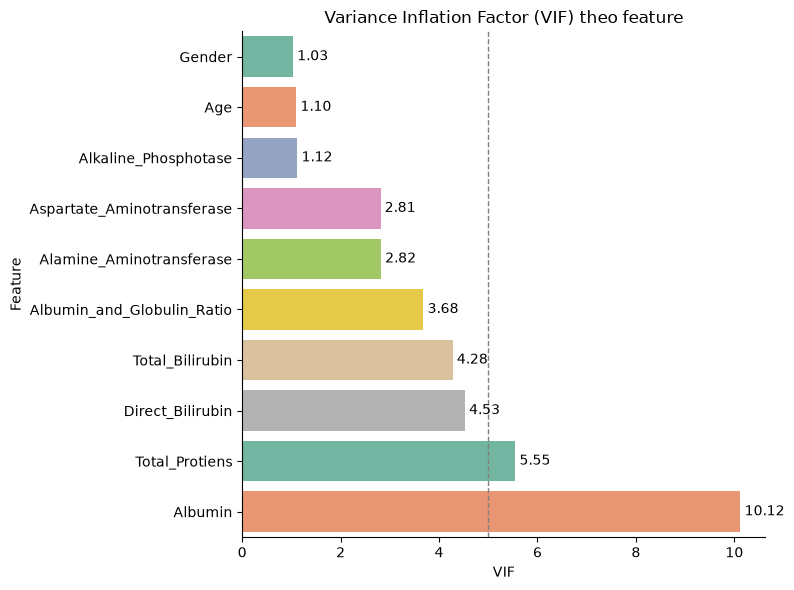

In [12]:
# Bar plot VIF theo feature
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=vif_df.sort_values('VIF'), y='Feature', x='VIF',
                 hue='Feature', palette='Set2', legend=False)
ax.axvline(5, color='gray', linestyle='--', linewidth=1)
ax.set_title('Variance Inflation Factor (VIF) theo feature')

# seaborn 0.13 tách mỗi bar thành 1 container riêng (do hue) -> label từng cái
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

## Phân phối các biến số (Boxplot)

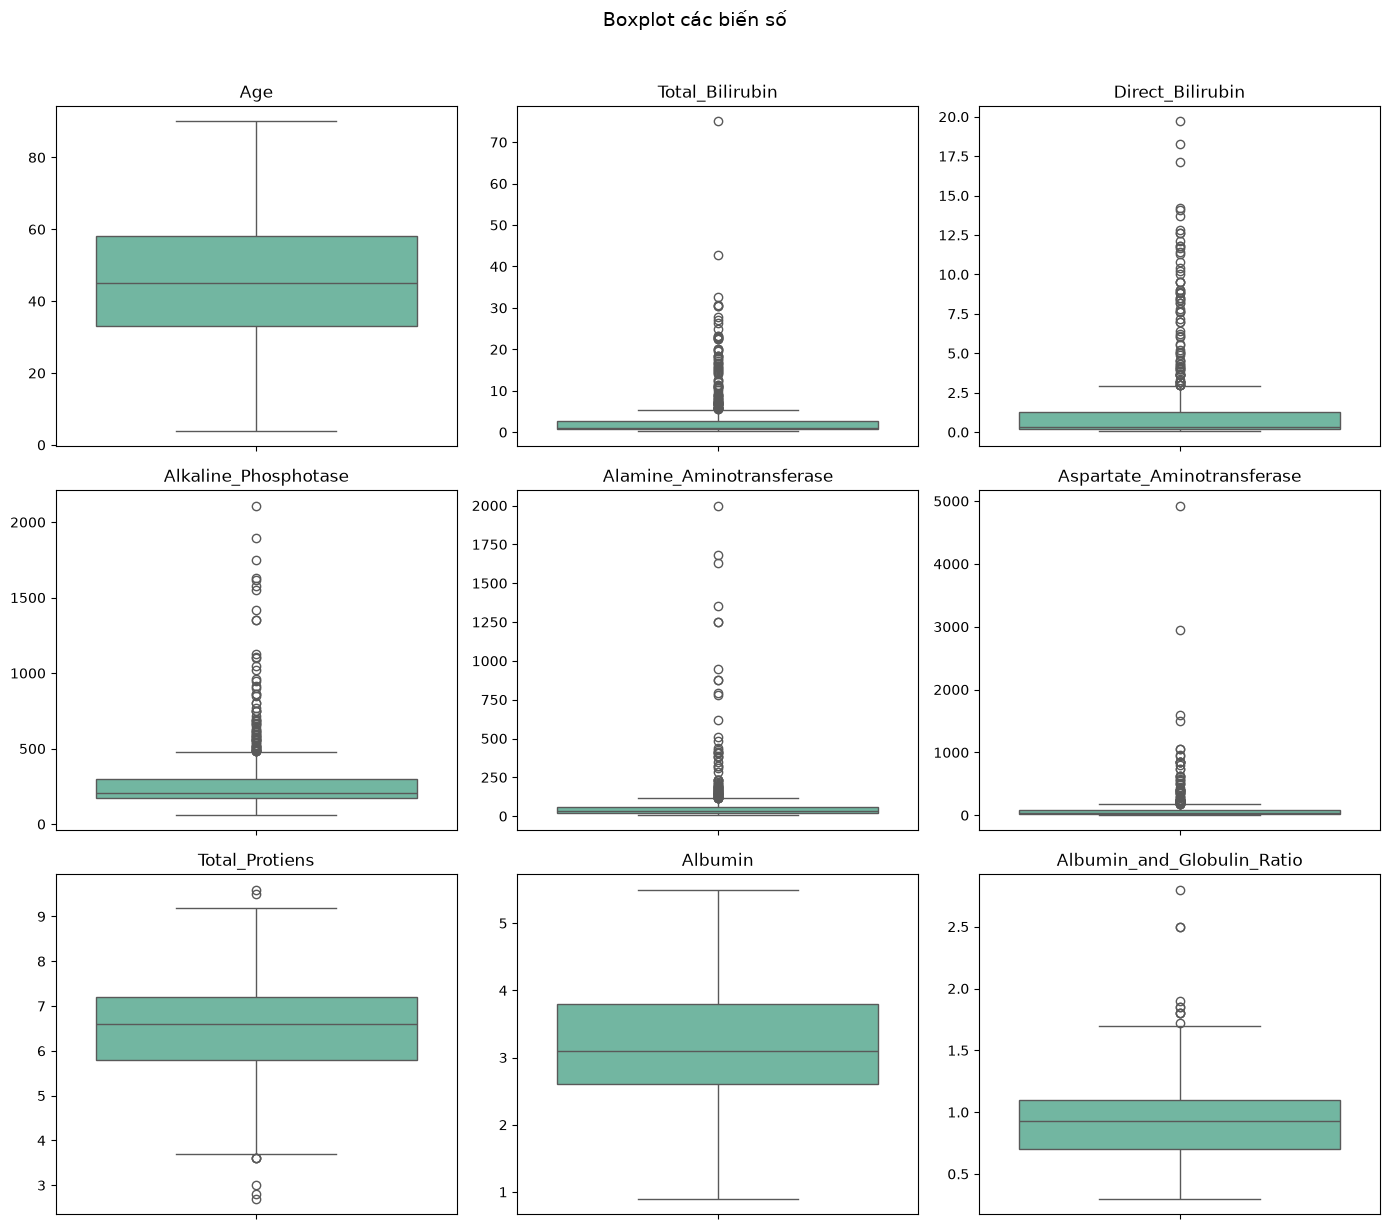

In [13]:
# Boxplot cho 9 biến số (bỏ Gender và Liver cirrhosis)
numeric_cols = df.drop(columns=['Gender', 'Liver cirrhosis']).columns

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#66c2a5')
    ax.set_title(col)
    ax.set_ylabel('')

plt.suptitle('Boxplot các biến số', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Xác định feature lệch phải nặng (skewness)

In [14]:
# Xác định các feature lệch phải nặng (skew > 1) dựa trên boxplot đã quan sát
skew = df[numeric_cols].skew().sort_values(ascending=False)
print(skew)

right_skewed_cols = skew[skew > 1].index.tolist()
print("\nFeature lệch phải nặng (skew > 1):", right_skewed_cols)

Aspartate_Aminotransferase    10.546177
Alamine_Aminotransferase       6.549192
Total_Bilirubin                4.907474
Alkaline_Phosphotase           3.765106
Direct_Bilirubin               3.212403
Albumin_and_Globulin_Ratio     0.992299
Age                           -0.029385
Albumin                       -0.043685
Total_Protiens                -0.285672
dtype: float64

Feature lệch phải nặng (skew > 1): ['Aspartate_Aminotransferase', 'Alamine_Aminotransferase', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Direct_Bilirubin']


## Thống kê (min, max, mean, median, std) theo nhóm target

In [15]:
# Thống kê (min, max, mean, median, std) theo từng nhóm target
numeric_cols = df.drop(columns=['Gender', 'Liver cirrhosis']).columns

group_stats = df.groupby('Liver cirrhosis')[numeric_cols].agg(
    ['min', 'max', 'mean', 'median', 'std']
).round(2).T

group_stats

Liver cirrhosis                          0        1
Age                        min        4.00     7.00
                           max       85.00    90.00
                           mean      41.24    46.15
                           median    40.00    46.00
                           std       17.00    15.65
Total_Bilirubin            min        0.50     0.40
                           max        7.30    75.00
                           mean       1.14     4.16
                           median     0.80     1.40
                           std        1.00     7.14
Direct_Bilirubin           min        0.10     0.10
                           max        3.60    19.70
                           mean       0.40     1.92
                           median     0.20     0.50
                           std        0.52     3.21
Alkaline_Phosphotase       min       90.00    63.00
                           max     1580.00  2110.00
                           mean     219.75   319.01
                           median   186.00   229.00
                           std      140.99   268.31
Alamine_Aminotransferase   min       10.00    12.00
                           max      181.00  2000.00
                           mean      33.65    99.61
                           median    27.00    41.00
                           std       25.06   212.77
Aspartate_Aminotransferase min       10.00    11.00
                           max      285.00  4929.00
                           mean      40.69   137.70
                           median    29.00    52.50
                           std       36.41   337.39
Total_Protiens             min        3.70     2.70
                           max        9.20     9.60
                           mean       6.54     6.46
                           median     6.60     6.55
                           std        1.06     1.09
Albumin                    min        1.40     0.90
                           max        5.00     5.50
                           mean       3.34     3.06
                           median     3.40     3.00
                           std        0.78     0.79
Albumin_and_Globulin_Ratio min        0.37     0.30
                           max        1.90     2.80
                           mean       1.03     0.91
                           median     1.00     0.90
                           std        0.29     0.33

## Boxplot các biến số theo nhóm target

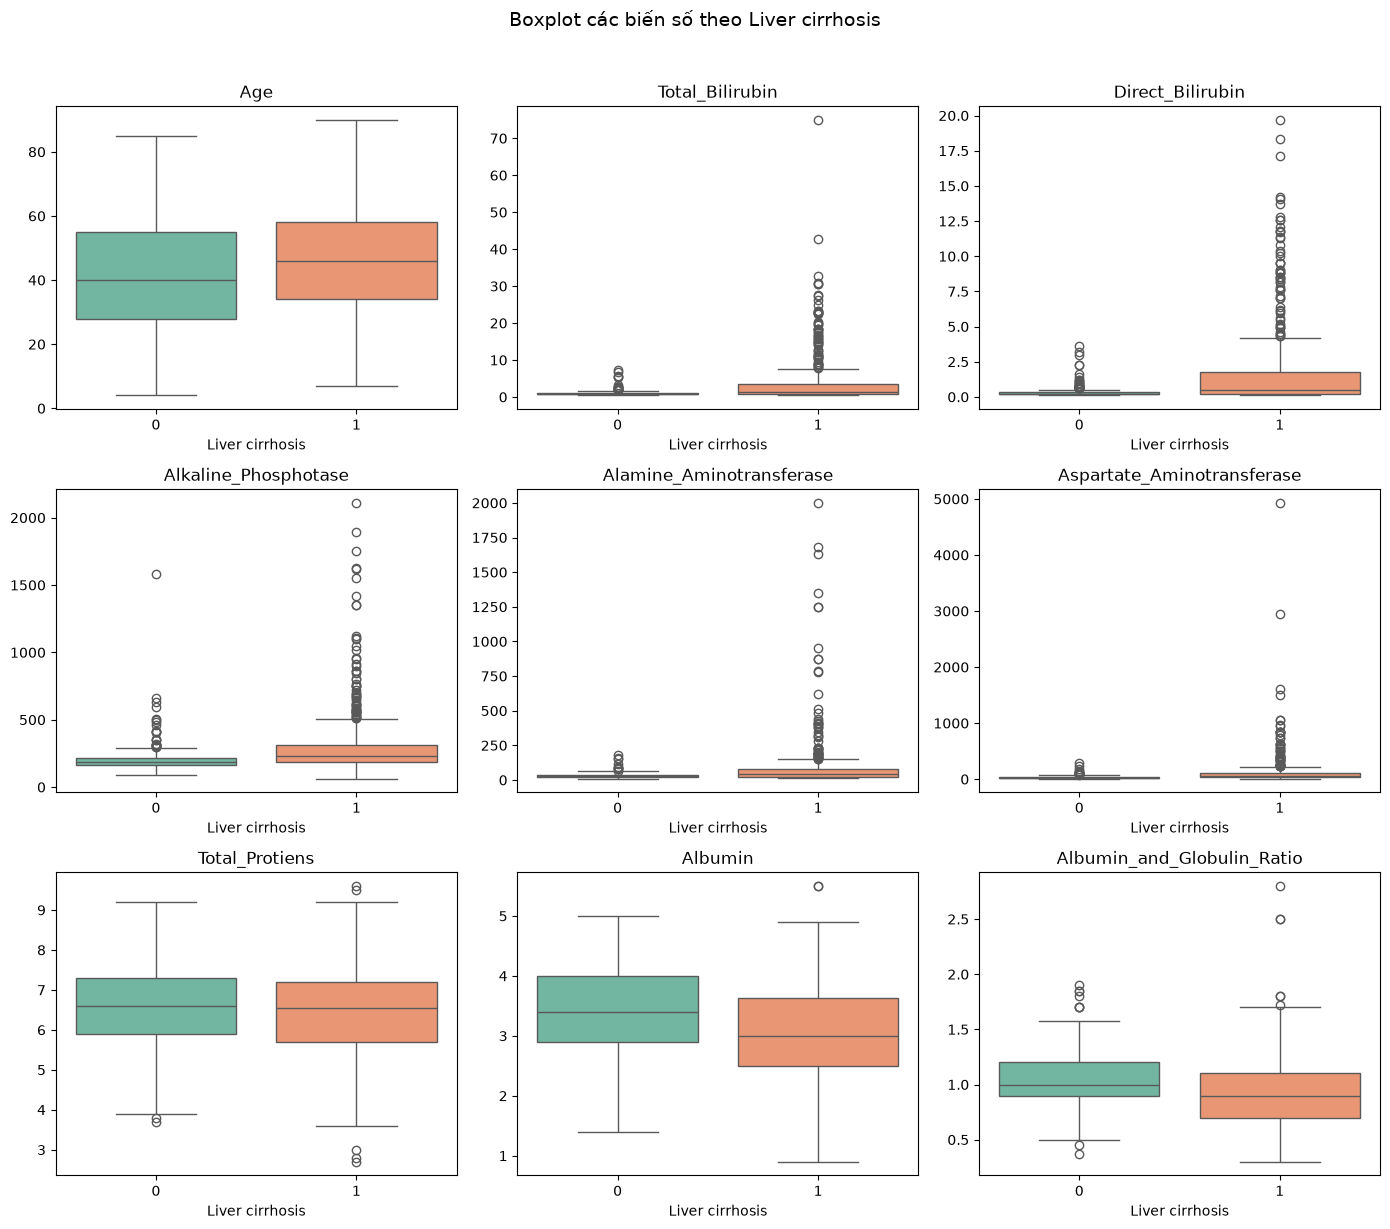

In [16]:
# Boxplot cho 9 biến số theo từng nhóm target (hue = Liver cirrhosis)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Liver cirrhosis', y=col, hue='Liver cirrhosis',
               palette='Set2', legend=False, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('Liver cirrhosis')

plt.suptitle('Boxplot các biến số theo Liver cirrhosis', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Quan hệ giữa Age và target (Violin plot)

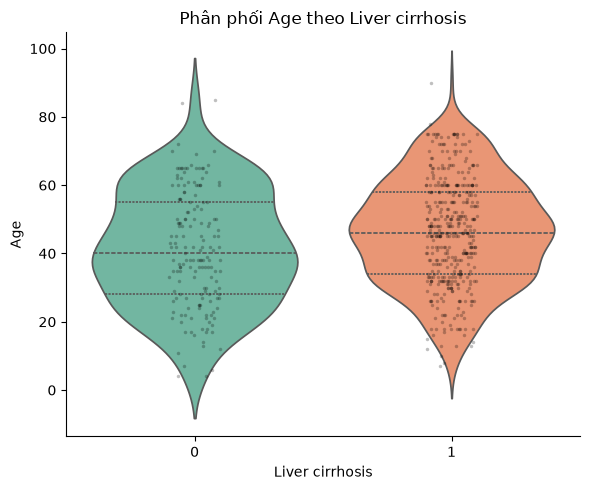

In [17]:
# Violin plot: quan hệ giữa Age và target (gộp boxplot + hình dạng phân phối)
plt.figure(figsize=(6, 5))
ax = sns.violinplot(data=df, x='Liver cirrhosis', y='Age', hue='Liver cirrhosis',
                    palette='Set2', inner='quart', legend=False)
sns.stripplot(data=df, x='Liver cirrhosis', y='Age', color='black', alpha=0.25, size=2.5, ax=ax)

ax.set_title('Phân phối Age theo Liver cirrhosis')
ax.set_xlabel('Liver cirrhosis')
ax.set_ylabel('Age')
sns.despine()
plt.tight_layout()
plt.show()

## Kiểm định thống kê cho feature selection (quan hệ với target)

In [18]:
# Mann-Whitney U test cho các biến liên tục theo target
# (dùng Mann-Whitney thay vì t-test vì phần lớn feature lệch phải nặng - đã xác định ở bước skewness,
#  và t-test giả định phân phối chuẩn nên không phù hợp ở đây)
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

group0 = df[df['Liver cirrhosis'] == 0]
group1 = df[df['Liver cirrhosis'] == 1]

results = []
for col in numeric_cols:
    g0, g1 = group0[col].dropna(), group1[col].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    # Rank-biserial correlation: effect size cho Mann-Whitney U (khoảng -1 đến 1)
    effect_size = 1 - (2 * stat) / (len(g0) * len(g1))
    results.append({'Feature': col, 'Test': 'Mann-Whitney U', 'Statistic': stat, 'p_value': p, 'Effect_size': effect_size})

# Gender: tái sử dụng kết quả Chi-square + Cramér's V đã tính ở phần trước
results.append({'Feature': 'Gender', 'Test': 'Chi-square', 'Statistic': chi2, 'p_value': p_value, 'Effect_size': cramers_v})

fs_df = pd.DataFrame(results)

# Hiệu chỉnh multiple testing (Benjamini-Hochberg FDR) vì chạy 10 kiểm định cùng lúc ở alpha=0.05
reject, p_adj, _, _ = multipletests(fs_df['p_value'], alpha=0.05, method='fdr_bh')
fs_df['p_value_fdr'] = p_adj
fs_df['Significant (FDR<0.05)'] = reject
fs_df = fs_df.sort_values('p_value').reset_index(drop=True)

fs_df

,Feature,Test,Statistic,p_value,Effect_size,p_value_fdr,Significant (FDR<0.05)
0,Aspartate_Aminotransferase,Mann-Whitney U,21035.000000,9.209662e-14,0.394432,9.209662e-13,True
1,Total_Bilirubin,Mann-Whitney U,21308.500000,2.289519e-13,0.386559,1.144759e-12,True
2,Direct_Bilirubin,Mann-Whitney U,21809.000000,7.431126e-13,0.372150,2.477042e-12,True
3,Alamine_Aminotransferase,Mann-Whitney U,21843.000000,2.332935e-12,0.371171,5.832338e-12,True
4,Alkaline_Phosphotase,Mann-Whitney U,22615.500000,4.347234e-11,0.348932,8.694469e-11,True
5,Albumin_and_Globulin_Ratio,Mann-Whitney U,42349.000000,5.812072e-06,-0.239906,9.686787e-06,True
6,Albumin,Mann-Whitney U,42141.000000,5.567004e-05,-0.213179,7.952863e-05,True
7,Age,Mann-Whitney U,28990.500000,1.774368e-03,0.165405,2.217960e-03,True
8,Gender,Chi-square,3.546649,5.966585e-02,0.082416,6.629539e-02,False
9,Total_Protiens,Mann-Whitney U,36164.500000,4.371466e-01,-0.041124,4.371466e-01,False


In [19]:
# Kết luận feature selection dựa trên p-value đã hiệu chỉnh FDR
selected_features = fs_df.loc[fs_df['Significant (FDR<0.05)'], 'Feature'].tolist()
dropped_features = fs_df.loc[~fs_df['Significant (FDR<0.05)'], 'Feature'].tolist()

print("Feature giữ lại (FDR-adjusted p < 0.05, có quan hệ với target):")
print(selected_features)
print("\nFeature loại bỏ (FDR-adjusted p >= 0.05, không đủ bằng chứng có quan hệ với target):")
print(dropped_features)

print("\nEffect size (rank-biserial / Cramér's V) theo độ mạnh giảm dần:")
print(fs_df[['Feature', 'Effect_size']].reindex(fs_df['Effect_size'].abs().sort_values(ascending=False).index).to_string(index=False))

Feature giữ lại (FDR-adjusted p < 0.05, có quan hệ với target):
['Aspartate_Aminotransferase', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alamine_Aminotransferase', 'Alkaline_Phosphotase', 'Albumin_and_Globulin_Ratio', 'Albumin', 'Age']

Feature loại bỏ (FDR-adjusted p >= 0.05, không đủ bằng chứng có quan hệ với target):
['Gender', 'Total_Protiens']

Effect size (rank-biserial / Cramér's V) theo độ mạnh giảm dần:
                   Feature  Effect_size
Aspartate_Aminotransferase     0.394432
           Total_Bilirubin     0.386559
          Direct_Bilirubin     0.372150
  Alamine_Aminotransferase     0.371171
      Alkaline_Phosphotase     0.348932
Albumin_and_Globulin_Ratio    -0.239906
                   Albumin    -0.213179
                       Age     0.165405
                    Gender     0.082416
            Total_Protiens    -0.041124


## Xây dựng mô hình: Logistic Regression & Random Forest (SMOTE)

In [20]:
# Chuẩn bị dữ liệu: bỏ Direct_Bilirubin (r=0.87 với Total_Bilirubin), Gender và Total_Protiens
# (không có ý nghĩa thống kê với target - FDR p>=0.05 ở bước feature selection); giữ Age
df_model = df.drop(columns=['Direct_Bilirubin', 'Gender', 'Total_Protiens']).copy()
df_model['Albumin_and_Globulin_Ratio'] = df_model['Albumin_and_Globulin_Ratio'].fillna(
    df_model['Albumin_and_Globulin_Ratio'].median()
)

X = df_model.drop(columns=['Liver cirrhosis'])
y = df_model['Liver cirrhosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nPhân bố target train (trước SMOTE):")
print(y_train.value_counts())

Train: (466, 7), Test: (117, 7)

Phân bố target train (trước SMOTE):
Liver cirrhosis
1    333
0    133
Name: count, dtype: int64


In [21]:
# Áp dụng SMOTE (chỉ trên tập train, không đụng vào tập test để tránh rò rỉ dữ liệu)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Phân bố target train (sau SMOTE):")
print(y_train_sm.value_counts())

Phân bố target train (sau SMOTE):
Liver cirrhosis
1    333
0    333
Name: count, dtype: int64


In [22]:
# Huấn luyện Logistic Regression và Random Forest trên dữ liệu đã SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression cần scale feature (khác thang đo lớn giữa các biến); Random Forest thì không cần
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sm_scaled, y_train_sm)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

print("Đã huấn luyện xong Logistic Regression và Random Forest.")

Đã huấn luyện xong Logistic Regression và Random Forest.


In [23]:
# Confusion matrix và classification report cho từng mô hình
models_pred = {'Logistic Regression': y_pred_log, 'Random Forest': y_pred_rf}

for name, y_pred in models_pred.items():
    print(f"===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Không bệnh (0)', 'Có bệnh (1)']))
    print()

===== Logistic Regression =====
Confusion Matrix:
[[28  6]
 [28 55]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.50      0.82      0.62        34
   Có bệnh (1)       0.90      0.66      0.76        83

      accuracy                           0.71       117
     macro avg       0.70      0.74      0.69       117
  weighted avg       0.78      0.71      0.72       117


===== Random Forest =====
Confusion Matrix:
[[12 22]
 [14 69]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.46      0.35      0.40        34
   Có bệnh (1)       0.76      0.83      0.79        83

      accuracy                           0.69       117
     macro avg       0.61      0.59      0.60       117
  weighted avg       0.67      0.69      0.68       117




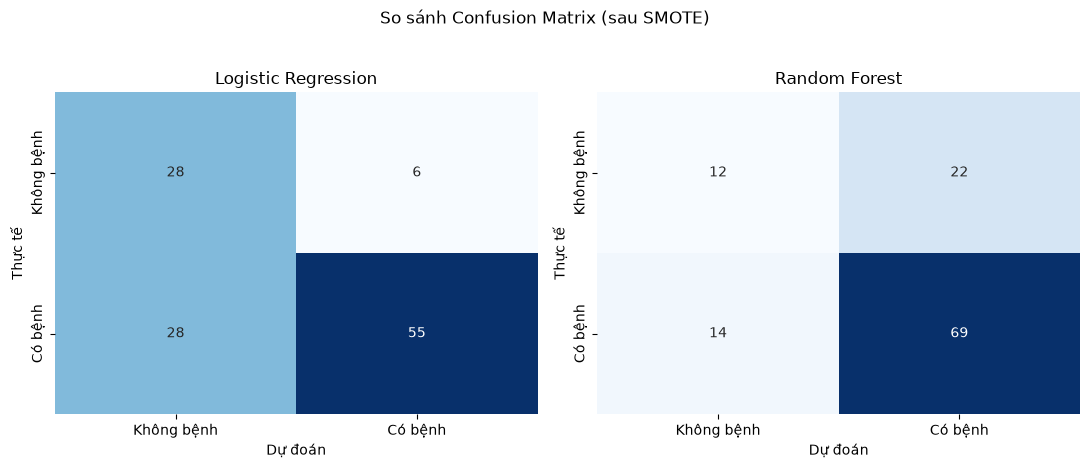

In [24]:
# So sánh trực quan Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_pred) in zip(axes, models_pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Không bệnh', 'Có bệnh'], yticklabels=['Không bệnh', 'Có bệnh'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
plt.suptitle('So sánh Confusion Matrix (sau SMOTE)', y=1.03)
plt.tight_layout()
plt.show()

In [25]:
# Bảng so sánh metrics tổng hợp giữa hai mô hình
rows = []
for name, y_pred in models_pred.items():
    report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
    rows.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (0)': report['0']['precision'],
        'Recall (0)': report['0']['recall'],
        'F1 (0)': report['0']['f1-score'],
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1 (1)': report['1']['f1-score'],
        'Macro F1': report['macro avg']['f1-score'],
    })

compare_df = pd.DataFrame(rows).set_index('Model').round(3)
compare_df

,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Macro F1
Model,,,,,,,,
Logistic Regression,0.709,0.500,0.824,0.622,0.902,0.663,0.764,0.693
Random Forest,0.692,0.462,0.353,0.400,0.758,0.831,0.793,0.597


## Điều chỉnh ngưỡng phân loại để ưu tiên recall lớp "có bệnh" (≥ 0.90)

In [26]:
# Ngưỡng mặc định (0.5) tối ưu cho độ chính xác tổng thể, không ưu tiên riêng lớp nào.
# Ở đây ta hạ ngưỡng quyết định để đạt recall >= 0.90 cho lớp "có bệnh" (1) - chấp nhận
# đánh đổi: nhiều người khỏe mạnh (0) bị dự đoán nhầm thành có bệnh, để không bỏ sót ca bệnh thật.
from sklearn.metrics import precision_recall_curve

def find_threshold_for_recall(y_true, y_proba, target_recall=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    valid = recall[:-1] >= target_recall
    if not valid.any():
        return thresholds.min(), recall[:-1].max()
    idx = np.where(valid)[0]
    best_idx = idx[np.argmax(thresholds[idx])]  # ngưỡng lớn nhất vẫn đạt recall mục tiêu -> precision tốt nhất có thể
    return thresholds[best_idx], recall[best_idx]

proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]

models_pred_tuned = {}
for name, proba in [('Logistic Regression', proba_log), ('Random Forest', proba_rf)]:
    thr, achieved_recall = find_threshold_for_recall(y_test, proba, target_recall=0.90)
    y_pred_tuned = (proba >= thr).astype(int)
    models_pred_tuned[name] = y_pred_tuned

    print(f"===== {name} (ngưỡng = {thr:.3f}, recall đạt được = {achieved_recall:.3f}) =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_tuned))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_tuned, target_names=['Không bệnh (0)', 'Có bệnh (1)']))
    print()

===== Logistic Regression (ngưỡng = 0.344, recall đạt được = 0.904) =====
Confusion Matrix:
[[14 20]
 [ 8 75]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.64      0.41      0.50        34
   Có bệnh (1)       0.79      0.90      0.84        83

      accuracy                           0.76       117
     macro avg       0.71      0.66      0.67       117
  weighted avg       0.74      0.76      0.74       117


===== Random Forest (ngưỡng = 0.387, recall đạt được = 0.904) =====
Confusion Matrix:
[[ 9 25]
 [ 8 75]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.53      0.26      0.35        34
   Có bệnh (1)       0.75      0.90      0.82        83

      accuracy                           0.72       117
     macro avg       0.64      0.58      0.59       117
  weighted avg       0.69      0.72      0.68       117




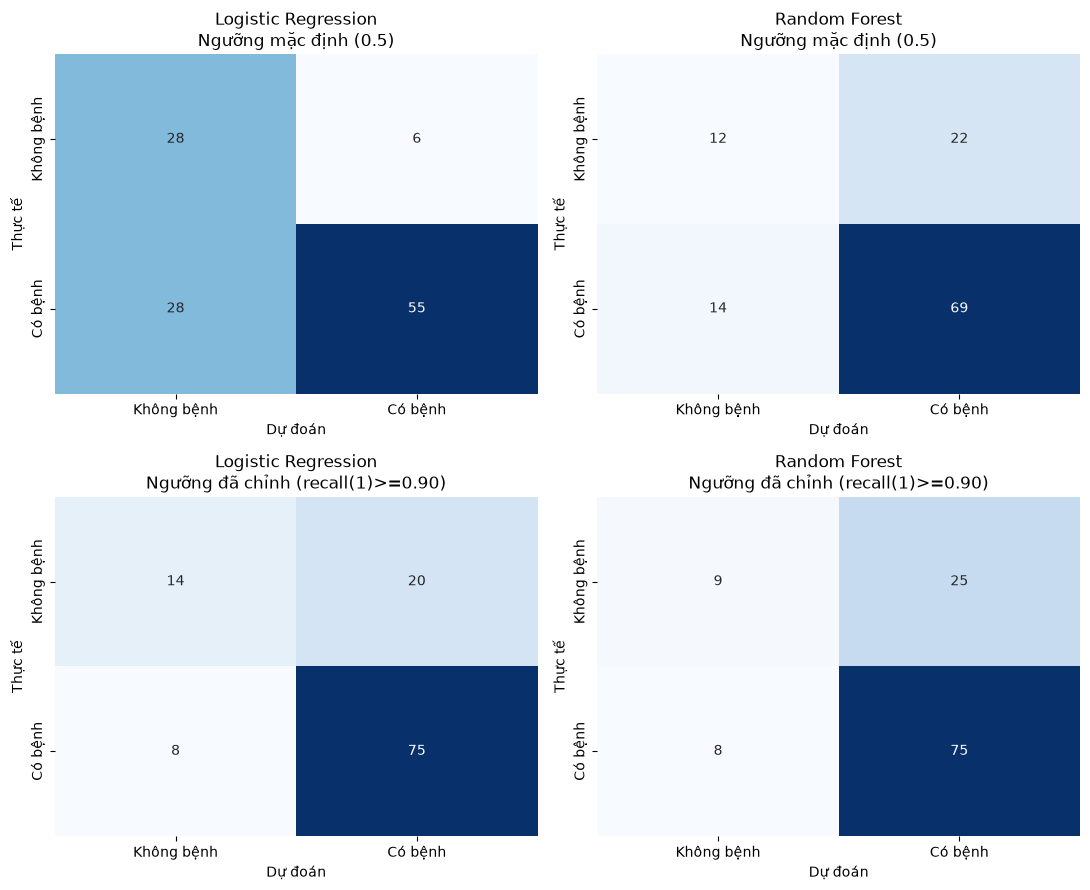

Accuracy  Recall (0)  Recall (1)  \
Model               Ngưỡng                                                      
Logistic Regression Mặc định (0.5)              0.709       0.824       0.663   
                    Đã chỉnh (recall>=0.90)     0.761       0.412       0.904   
Random Forest       Mặc định (0.5)              0.692       0.353       0.831   
                    Đã chỉnh (recall>=0.90)     0.718       0.265       0.904   

                                             Precision (1)  Macro F1  
Model               Ngưỡng                                            
Logistic Regression Mặc định (0.5)                   0.902     0.693  
                    Đã chỉnh (recall>=0.90)          0.789     0.671  
Random Forest       Mặc định (0.5)                   0.758     0.597  
                    Đã chỉnh (recall>=0.90)          0.750     0.586

In [27]:
# So sánh trực quan: ngưỡng mặc định (0.5) vs ngưỡng đã chỉnh (recall >= 0.90)
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for col, (name, y_pred_default) in enumerate(models_pred.items()):
    y_pred_tuned = models_pred_tuned[name]
    for row, (title, y_pred) in enumerate([('Ngưỡng mặc định (0.5)', y_pred_default),
                                            ('Ngưỡng đã chỉnh (recall(1)>=0.90)', y_pred_tuned)]):
        ax = axes[row, col]
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                   xticklabels=['Không bệnh', 'Có bệnh'], yticklabels=['Không bệnh', 'Có bệnh'], ax=ax)
        ax.set_title(f'{name}\n{title}')
        ax.set_xlabel('Dự đoán')
        ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

# Bảng so sánh metrics: mặc định vs đã chỉnh ngưỡng
rows = []
for name in models_pred:
    for variant, y_pred in [('Mặc định (0.5)', models_pred[name]), ('Đã chỉnh (recall>=0.90)', models_pred_tuned[name])]:
        report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
        rows.append({
            'Model': name, 'Ngưỡng': variant,
            'Accuracy': report['accuracy'],
            'Recall (0)': report['0']['recall'],
            'Recall (1)': report['1']['recall'],
            'Precision (1)': report['1']['precision'],
            'Macro F1': report['macro avg']['f1-score'],
        })

pd.DataFrame(rows).set_index(['Model', 'Ngưỡng']).round(3)